#21BAI1499 - LAB 7

#**Task 1:** Perform Region Growing based segmentation for an input image. Consider 4-pixel neighborhood and use intensity difference as an similarity criteria. Use a queue to store your selected is the points. Finally when your iteration is complete display only the extracted regions whi segmented output.


##Normal Image

In [ ]:
import cv2
import numpy as np
from queue import Queue
import matplotlib.pyplot as plt

Load Image

In [ ]:
img = cv2.imread('coin.jpg', cv2.IMREAD_GRAYSCALE)

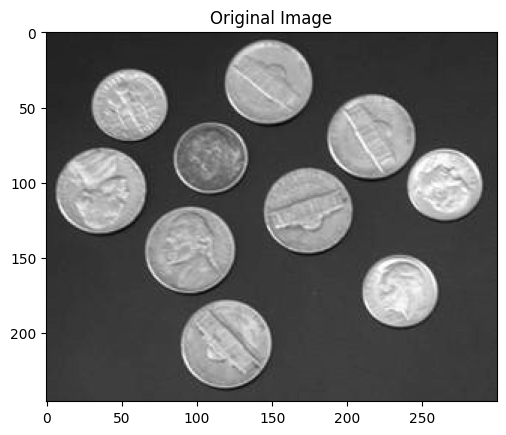

In [ ]:
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.show()

In [ ]:
'''
import cv2

def click_event(event, x, y, flags, params):
   if event == cv2.EVENT_LBUTTONDOWN:
      print(f'({x},{y})')

cv2.namedWindow('og')
cv2.setMouseCallback('og', click_event)
img = cv2.imread('coin.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('og', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Coordinates
(52,48)
(34,107)
(94,143)
(120,203)
(108,89)
(177,132)
(232,167)
(155,30)
(221,70)
(268,103)
'''

"\nimport cv2\n\ndef click_event(event, x, y, flags, params):\n   if event == cv2.EVENT_LBUTTONDOWN:\n      print(f'({x},{y})')\n\ncv2.namedWindow('og')\ncv2.setMouseCallback('og', click_event)\nimg = cv2.imread('coin.jpg', cv2.IMREAD_GRAYSCALE)\ncv2.imshow('og', img)\ncv2.waitKey(0)\ncv2.destroyAllWindows()\n\nCoordinates\n(52,48)\n(34,107)\n(94,143)\n(120,203)\n(108,89)\n(177,132)\n(232,167)\n(155,30)\n(221,70)\n(268,103)\n"

Initialize

In [ ]:
seeds = [
    (52, 48),
    (34, 107),
    (94, 143),
    (120, 203),
    (108, 89),
    (177, 132),
    (232, 167),
    (155, 30),
    (221, 70),
    (268, 103)
]

coins = []
threshold = 12

Perform Region growing

In [ ]:
def region_growing(image, seed, threshold):
    height, width = image.shape[:2]
    segmented = np.zeros((height, width), np.uint8)

    # Define 4-pixel neighborhood
    dx = [-1, 1, 0, 0]
    dy = [0, 0, -1, 1]

    # Initialize queue with seed point
    q = Queue()
    q.put(seed)
    segmented[seed[1], seed[0]] = 255

    while not q.empty():
        x, y = q.get()
        for i in range(4):
            nx, ny = x + dx[i], y + dy[i]
            if 0 <= nx < width and 0 <= ny < height:
                if segmented[ny, nx] == 0 and abs(int(image[y, x]) - int(image[ny, nx])) <= threshold:
                    segmented[ny, nx] = 255
                    q.put((nx, ny))

    return segmented

In [ ]:
for seed in seeds:
    segmented = region_growing(img, seed, threshold)
    coins.append(segmented)

Display

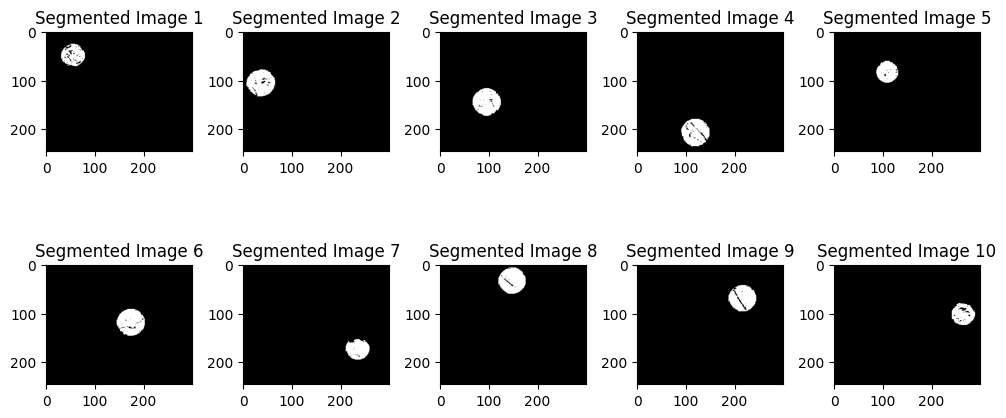

In [ ]:
sub = 1

plt.figure(figsize=(10, 5))
for coin in coins:
  plt.subplot(2, 5, sub)
  plt.imshow(coin, cmap='gray')
  plt.title("Segmented Image " + str(sub))
  sub += 1

plt.tight_layout()
plt.show()

###Inference:
The region growing algorithm has successfully isolated each coin as a separate segment. The segmented regions closely match the circular shapes of the coins. Each seed point was placed within each coin and each segmented image appears to represent the respective single coin.
The clear separation of coins suggests that the threshold of 12 for intensity difference was set appropriately.
Some segmented coins (e.g., Segmented Image 4) show internal details whereas others (e.q., Segmented Image 7) hasn't even captured the full coin

##Study the impact of seed point selection and noisy input image.

In [ ]:
img = cv2.imread('noisy_cameraman.jpg', cv2.IMREAD_GRAYSCALE)

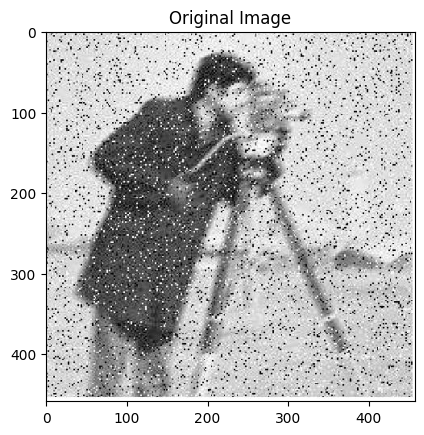

In [ ]:
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.show()

In [ ]:
seed = (147, 247)
thresholds = [10, 15, 25, 50, 75, 100, 200]
outputs = []

In [ ]:
for threshold in thresholds:
    segmented = region_growing(img, seed, threshold)
    outputs.append(segmented)

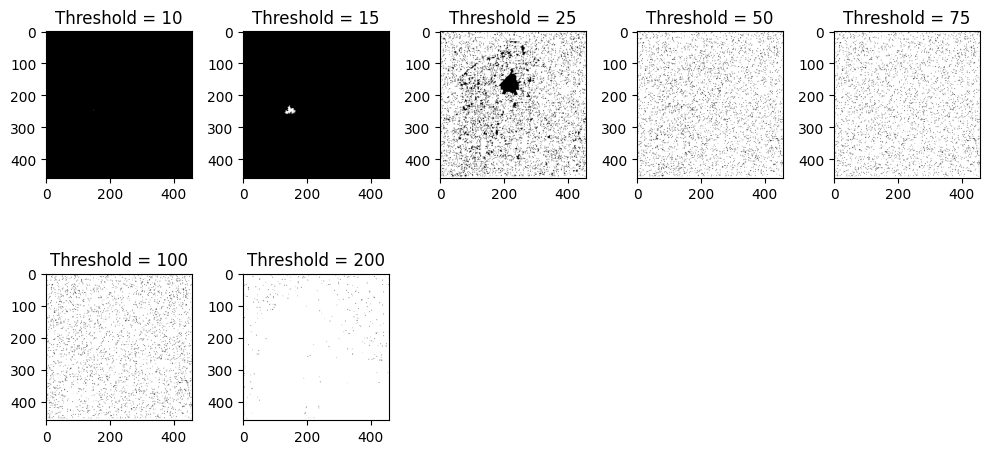

In [ ]:
sub = 1

plt.figure(figsize=(10, 5))
for output in outputs:
  plt.subplot(2, 5, sub)
  plt.imshow(output, cmap='gray')
  plt.title("Threshold = " + str(thresholds[sub-1]))
  sub += 1

plt.tight_layout()
plt.show()

###Inference:
Region growing is highly sensitive to noise, as evidenced by the scattered segmentation results, at all thresholds. The main subject (person with camera) is not clearly segmented at any threshold, contrasting with the clear coin segmentations.
Higher thresholds lead to over-segmentation, including noise pixels, while lower thresholds fail to capture the subject. The noisy image lacks distinct intensity boundaries, making it challenging for region growing to differentiate between object and background.

#Task 2: Perform segmentation of an input image (take astronaut image or coin image) using Active Contour Model. Initialize a suitable spline to perform the segmentation.